# 06 · Hypothesentest — Favorita

## 0 · Imports & Setup

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import sys

sys.path.append(os.path.abspath('../03_src'))

from utilis import mape, rmse, compute_metrics, load_preds
from config import (
    PROCESSED, FINAL, TARGET_COL, FEATURE_COLS,
    EXOG_COLS, STAT_EXOG, HIST_EXOG,
    TRAIN_END, VAL_END, LOOKBACK, HORIZON,
    MODELL_ORDER, MODELL_COLORS, PRED_COLS, RESULTS, FILE_NAMES
)

sns.set_style('whitegrid')


## 1 - Daten laden

In [64]:
df = pl.read_parquet(FINAL / 'final_dataset.parquet')

train     = df.filter(pl.col('date') <= TRAIN_END)
val       = df.filter((pl.col('date') > TRAIN_END) & (pl.col('date') <= VAL_END))
test      = df.filter(pl.col('date') > VAL_END)
train_val = df.filter(pl.col('date') <= VAL_END)

stores = sorted(df['store_nbr'].unique().to_list())

print(f'Train:     {train.shape}  {train["date"].min()} → {train["date"].max()}')
print(f'Val:       {val.shape}    {val["date"].min()} → {val["date"].max()}')
print(f'Test:      {test.shape}   {test["date"].min()} → {test["date"].max()}')
print(f'Stores:    {len(stores)}')

Train:     (70114, 37)  2013-01-29 → 2016-12-31
Val:       (7965, 37)    2017-01-01 → 2017-05-31
Test:      (4104, 37)   2017-06-01 → 2017-08-15
Stores:    54


## 2 · Ausgangsdatensatz

In [65]:
models_cfg = {
    'XGBoost':  'pred_xgb',
    'LightGBM': 'pred_lgbm',
    'PatchTST': 'pred_patchtst',
    'NHITS':    'pred_nhits',
    'SARIMAX':  'pred_sarimax',
    'Prophet':  'pred_prophet',
}
models_cfg

{'XGBoost': 'pred_xgb',
 'LightGBM': 'pred_lgbm',
 'PatchTST': 'pred_patchtst',
 'NHITS': 'pred_nhits',
 'SARIMAX': 'pred_sarimax',
 'Prophet': 'pred_prophet'}

In [66]:
base = (
    test.select(['store_nbr', 'date', TARGET_COL])
    .rename({TARGET_COL: 'y_true'})
    .to_pandas()
)


In [67]:
for name, col in models_cfg.items():
    fname = f'test_{name.lower()}.parquet'
    try:
        pred_df = pl.read_parquet(RESULTS / fname).to_pandas()
        base = base.merge(pred_df[['store_nbr', 'date', col]],
                          on=['store_nbr', 'date'], how='left')
    except FileNotFoundError:
        print(f'Nicht gefunden: {fname}')

In [68]:

stores_pd = pl.read_parquet(PROCESSED / 'stores.parquet').to_pandas()
base = base.merge(stores_pd[['store_nbr', 'type', 'cluster']],
                  on='store_nbr', how='left')
base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster
0,1,2017-06-01,1815,1816.982300,1809.406816,1660.943970,1671.510742,1602.027703,1685.763841,D,13
1,1,2017-06-02,1925,1979.134888,1919.192006,1565.402954,1618.768677,1454.307586,1702.832804,D,13
2,1,2017-06-03,1420,1426.523315,1406.175371,1360.430908,1562.789307,1240.680557,1246.257371,D,13
3,1,2017-06-04,525,525.163391,532.730107,474.035034,1319.485718,545.854603,459.782668,D,13
4,1,2017-06-05,1883,1881.178955,1892.467546,1192.562134,1697.511353,1669.458555,1676.592816,D,13
...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,770.002380,774.441403,843.519897,1286.097900,771.595969,754.592989,C,3
4100,54,2017-08-12,903,896.292053,901.082840,868.788513,1402.123169,946.317499,932.948913,C,3
4101,54,2017-08-13,1054,1054.234619,1053.828172,1003.213318,1400.005615,1084.098506,1100.898020,C,3
4102,54,2017-08-14,818,819.478394,817.904740,946.838257,1308.153076,822.844112,822.234089,C,3


In [69]:
# ── Metriken je Store ─────────────────────────────────────
store_metrics = []
for store_id, grp in base.groupby('store_nbr'):
    for model_name, col in models_cfg.items():
        if col not in grp.columns or grp[col].isna().all():
            continue
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        store_metrics.append({
            'store_nbr':  store_id,
            'model':      model_name,
            'store_type': grp['type'].iloc[0],
            'MAE':        mean_absolute_error(y_true, y_pred),
            'RMSE':       rmse(y_true, y_pred),
            'MAPE':       mape(y_true, y_pred),
            'std_true':   y_true.std(),
            'acf_lag7':   pd.Series(y_true).autocorr(lag=7),
        })

metrics_df = pd.DataFrame(store_metrics)

# ── Gesamtübersicht ───────────────────────────────────────
summary = metrics_df.groupby('model')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary.sort_values('MAE'))

             MAE    RMSE   MAPE
model                          
XGBoost     6.27    8.59   0.35
LightGBM    9.47   12.23   0.57
PatchTST  101.19  128.90   6.77
SARIMAX   105.96  135.87   6.71
Prophet   248.39  300.35  12.93
NHITS     285.43  316.48  21.03


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\2925250569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


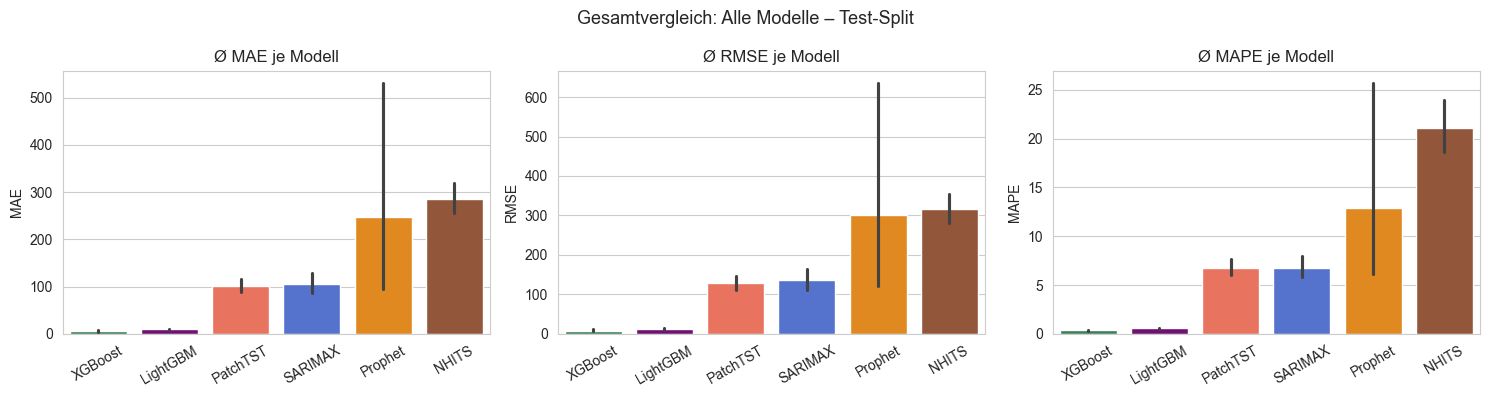

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = summary.sort_values('MAE').index.tolist()
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    sns.barplot(
        data=metrics_df, x='model', y=metric,
        order=order,
        palette=MODELL_COLORS,
        ax=axes[i]
    )
    axes[i].set_title(f'Ø {metric} je Modell', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Gesamtvergleich: Alle Modelle – Test-Split', fontsize=13)
plt.tight_layout()
plt.show()

### H1: Wenn keine filialspezifische Normalisierung angewendet wird, dann erzielen Gradient-Boosting-Verfahren bei rechtsschiefen Transaktionsdaten mit Extremwerten eine höhere Prognosegenauigkeit als Deep-Learning-Architekturen.

#### Metrik: MAE (absoluter Fehler) und RMSE (bestraft Extremwerte
#### überproportional → direkt relevant für Rechtsschiefen-Hypothese)
#### Bestätigt wenn: MAE/RMSE von XGBoost oder LightGBM < PatchTST und NHITS

H1: GB vs. Deep Learning – MAE / RMSE

Bestes Modell:     XGBoost (MAE 6.3)
Schlechtestes:     NHITS (MAE 285.4)
Ø GB-MAE:          7.9
Ø DL-MAE:          193.3
H1 BESTÄTIGT ✓


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\427780395.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\427780395.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


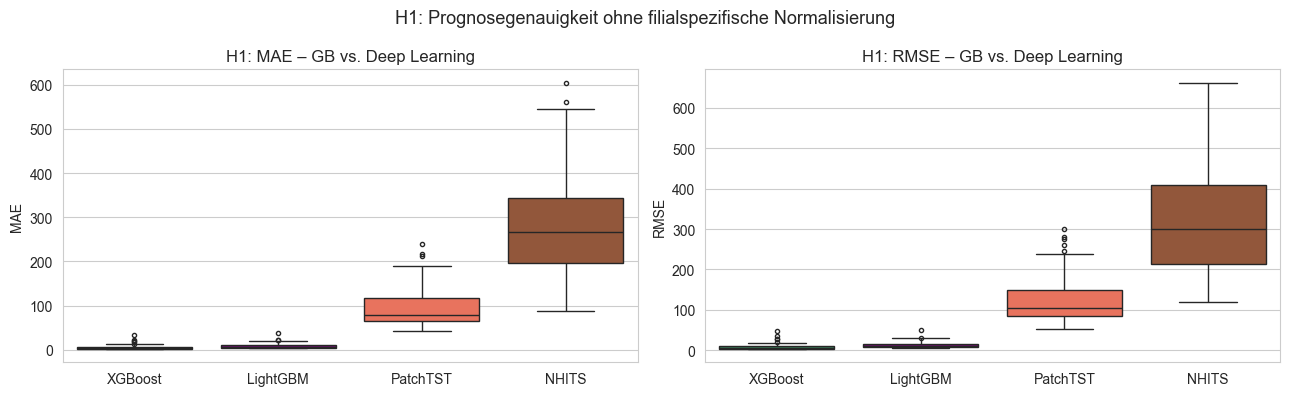

In [71]:
print('H1: GB vs. Deep Learning – MAE / RMSE')

h1_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h1_df     = metrics_df[metrics_df['model'].isin(h1_models)]

h1_summary =  h1_df.groupby('model')[['MAE', 'RMSE']].mean().round(1).sort_values('MAE')

best_h1  = h1_summary['MAE'].idxmin()
worst_h1 = h1_summary['MAE'].idxmax()
print(f'\nBestes Modell:     {best_h1} (MAE {h1_summary.loc[best_h1, "MAE"]:.1f})')
print(f'Schlechtestes:     {worst_h1} (MAE {h1_summary.loc[worst_h1, "MAE"]:.1f})')
gb_mae  = h1_df[h1_df['model'].isin(['XGBoost','LightGBM'])]['MAE'].mean()
dl_mae  = h1_df[h1_df['model'].isin(['PatchTST','NHITS'])]['MAE'].mean()
print(f'Ø GB-MAE:          {gb_mae:.1f}')
print(f'Ø DL-MAE:          {dl_mae:.1f}')
print(f'H1 {"BESTÄTIGT ✓" if gb_mae < dl_mae else "WIDERLEGT ✗"}')

# ── Boxplot: Verteilung je Store ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, metric in enumerate(['MAE', 'RMSE']):
    sns.boxplot(
        data=h1_df, x='model', y=metric,
        order=h1_models,
        palette=[MODELL_COLORS[m] for m in h1_models],
        flierprops={'markersize': 3}, ax=axes[i]
    )
    axes[i].set_title(f'H1: {metric} – GB vs. Deep Learning', fontsize=12)
    axes[i].set_xlabel('')
plt.suptitle('H1: Prognosegenauigkeit ohne filialspezifische Normalisierung',
             fontsize=13)
plt.tight_layout()
plt.show()

### H2: Wenn Feiertagsereignisse im Trainingszeitraum nur selten auftreten, dann weisen featuregetriebene Modelle durch explizite Kalender-Features eine geringere Fehlerquote bei der Feiertagsprognose auf als sequenzbasierte Deep-Learning-Architekturen.

#### Metrik: MAE separat für Feiertags- und Normaltage.
#### Relativer Anstieg = (MAE_Feiertag - MAE_Normal) / MAE_Normal * 100
#### Ein geringerer Anstieg bei GB bestätigt H2.

In [72]:
hol_national = pd.read_parquet(FINAL / 'holiday_features.parquet')
hol_national

,date,is_national_holiday
0,2013-01-02,False
1,2013-01-03,False
2,2013-01-04,False
3,2013-01-05,True
4,2013-01-06,False
...,...,...
1675,2017-08-11,True
1676,2017-08-12,False
1677,2017-08-13,False
1678,2017-08-14,False


In [73]:
base['date'] = base['date'].astype(str)
hol_national['date'] = hol_national['date'].astype(str)
hol_base = base.merge(hol_national, on='date', how='left')
hol_base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster,is_national_holiday
0,1,2017-06-01,1815,1816.982300,1809.406816,1660.943970,1671.510742,1602.027703,1685.763841,D,13,False
1,1,2017-06-02,1925,1979.134888,1919.192006,1565.402954,1618.768677,1454.307586,1702.832804,D,13,False
2,1,2017-06-03,1420,1426.523315,1406.175371,1360.430908,1562.789307,1240.680557,1246.257371,D,13,False
3,1,2017-06-04,525,525.163391,532.730107,474.035034,1319.485718,545.854603,459.782668,D,13,False
4,1,2017-06-05,1883,1881.178955,1892.467546,1192.562134,1697.511353,1669.458555,1676.592816,D,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,770.002380,774.441403,843.519897,1286.097900,771.595969,754.592989,C,3,True
4100,54,2017-08-12,903,896.292053,901.082840,868.788513,1402.123169,946.317499,932.948913,C,3,False
4101,54,2017-08-13,1054,1054.234619,1053.828172,1003.213318,1400.005615,1084.098506,1100.898020,C,3,False
4102,54,2017-08-14,818,819.478394,817.904740,946.838257,1308.153076,822.844112,822.234089,C,3,False


In [74]:
hol_records = []
h2_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']

for model_name, col in {m: models_cfg[m] for m in h2_models}.items():
    if col not in hol_base.columns:
        continue
    for is_hol, grp in hol_base.groupby('is_national_holiday'):
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        if len(y_true) == 0:
            continue
        hol_records.append({
            'model':      model_name,
            'is_national_holiday': 'Feiertag' if is_hol else 'Normal',
            'MAE':        mean_absolute_error(y_true, y_pred),
            'n':          len(y_true),
        })

hol_metrics = pd.DataFrame(hol_records)

is_national_holiday  Feiertag  Normal  Anstieg (%)
model                                             
LightGBM                 12.7     9.4         35.1
NHITS                   441.9   283.3         56.0
PatchTST                196.8    99.9         96.9
XGBoost                   7.1     6.3         12.9

Ø Fehleranstieg GB: 24.0%
Ø Fehleranstieg DL: 76.5%
H2 BESTÄTIGT ✓


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1366189858.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


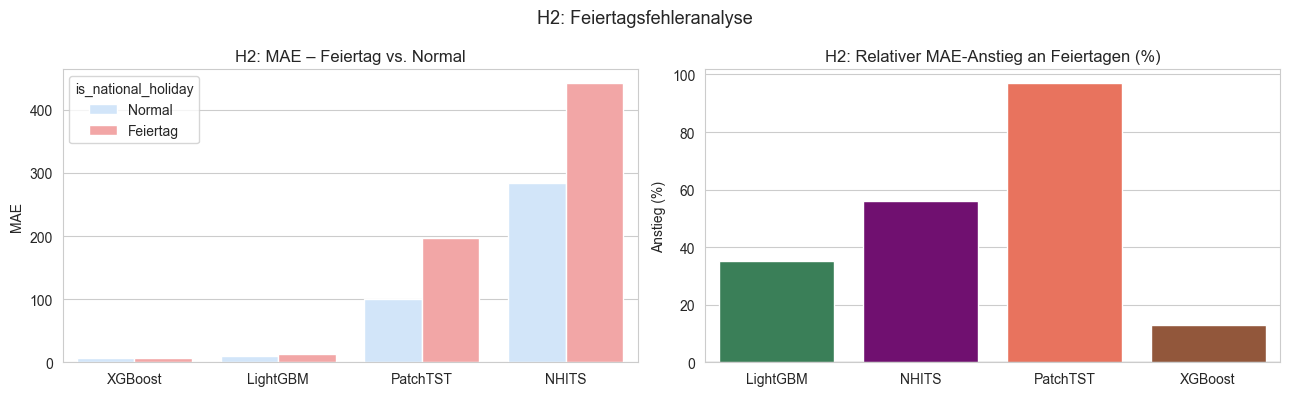

In [75]:


# ── Relativer MAE-Anstieg an Feiertagen ──────────────────────
pivot = hol_metrics.pivot(index='model', columns='is_national_holiday', values='MAE')
pivot['Anstieg (%)'] = (
    (pivot['Feiertag'] - pivot['Normal']) / pivot['Normal'] * 100
).round(1)
print(pivot.round(1))

# ── Interpretation ────────────────────────────────────────────
gb_anstieg = pivot.loc[['XGBoost', 'LightGBM'], 'Anstieg (%)'].mean()
dl_anstieg = pivot.loc[['PatchTST', 'NHITS'], 'Anstieg (%)'].mean()
print(f'\nØ Fehleranstieg GB: {gb_anstieg:.1f}%')
print(f'Ø Fehleranstieg DL: {dl_anstieg:.1f}%')
print(f'H2 {"BESTÄTIGT ✓" if gb_anstieg < dl_anstieg else "WIDERLEGT ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(
    data=hol_metrics, x='model', y='MAE',
    hue='is_national_holiday', hue_order=['Normal', 'Feiertag'],
    palette={'Normal': '#cce5ff', 'Feiertag': '#ff9999'},
    ax=axes[0]
)
axes[0].set_title('H2: MAE – Feiertag vs. Normal', fontsize=12)
axes[0].set_xlabel('')

sns.barplot(
    data=pivot.reset_index(), x='model', y='Anstieg (%)',
    palette=[MODELL_COLORS[m] for m in h2_models], ax=axes[1]
)
axes[1].set_title('H2: Relativer MAE-Anstieg an Feiertagen (%)', fontsize=12)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('')

plt.suptitle('H2: Feiertagsfehleranalyse', fontsize=13)
plt.tight_layout()
plt.show()


### H3: Wenn stark autokorrelierte Zeitreihenabschnitte vorliegen, dann bildet die Deep-Learning-Architekturen die Dynamiken ohne explizites Feature Engineering ebenso präzise oder präziser ab als Gradient-Boosting-Verfahren.

#### Metrik: MAPE (skalierungsunabhängig für Filialvergleiche)
#### Schwellenwert ACF > 0.7: überdurchschnittlich stark autokorreliert
#### (Median über alle Stores: ~0.63)
#### Bestätigt wenn: DL-MAPE ≤ GB-MAPE bei diesen Stores

In [76]:

high_acf  = metrics_df[metrics_df['acf_lag7'] > 0.7]
h3_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h3_df     = high_acf[high_acf['model'].isin(h3_models)]
n_stores_high = high_acf['store_nbr'].nunique()
h3_summary = h3_df.groupby('model')['MAPE'].mean().round(2).sort_values()
h3_summary

model
XGBoost      0.33
LightGBM     0.54
PatchTST     6.56
NHITS       20.26
Name: MAPE, dtype: float64

In [77]:
gb_mape_h3 = h3_df[h3_df['model'].isin(['XGBoost','LightGBM'])]['MAPE'].mean()
dl_mape_h3 = h3_df[h3_df['model'].isin(['PatchTST','NHITS'])]['MAPE'].mean()
print(f'\nØ GB-MAPE (ACF>0.7): {gb_mape_h3:.2f}%')
print(f'Ø DL-MAPE (ACF>0.7): {dl_mape_h3:.2f}%')
print(f'H3 {"BESTÄTIGT ✓" if dl_mape_h3 <= gb_mape_h3 else "WIDERLEGT ✗"}')


Ø GB-MAPE (ACF>0.7): 0.43%
Ø DL-MAPE (ACF>0.7): 13.41%
H3 WIDERLEGT ✗


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\2546439223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


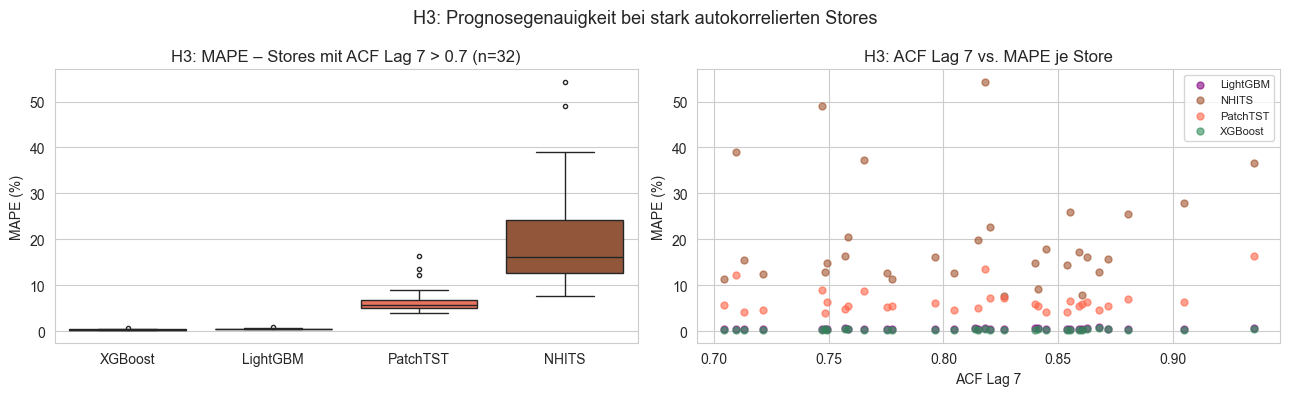

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot: MAPE-Verteilung je Modell bei hoher ACF
sns.boxplot(
    data=h3_df, x='model', y='MAPE',
    order=h3_models,
    palette=[MODELL_COLORS[m] for m in h3_models],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title(f'H3: MAPE – Stores mit ACF Lag 7 > 0.7 (n={n_stores_high})',
                  fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAPE (%)')

# Scatterplot: ACF Lag 7 vs. MAPE – zeigt ob Vorteil mit ACF zunimmt
for model_name, grp in h3_df.groupby('model'):
    axes[1].scatter(
        grp['acf_lag7'], grp['MAPE'],
        label=model_name, alpha=0.6, s=25,
        color=MODELL_COLORS[model_name]
    )
axes[1].set_title('H3: ACF Lag 7 vs. MAPE je Store', fontsize=12)
axes[1].set_xlabel('ACF Lag 7')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.suptitle('H3: Prognosegenauigkeit bei stark autokorrelierten Stores',
             fontsize=13)
plt.tight_layout()
plt.show()

## H4: Wenn exogene Faktoren ohne relevante lineare oder nicht-lineare Korrelationen integriert werden, dann führt dies unabhängig von der Modellarchitektur zu keiner signifikanten Verbesserung der Prognosegüte.

####  Direkter Vergleich: NHITS (mit Exogenen) vs. PatchTST (ohne). Bei GB sind Exogene als Features kodiert → als Referenz mitgezeigt.
#### Metrik: MAE und MAPE. Bestätigt wenn: NHITS kein konsistenter Vorteil vs. PatchTST

In [79]:
h4_models = ['PatchTST', 'NHITS', 'XGBoost', 'LightGBM']
h4_df     = metrics_df[metrics_df['model'].isin(h4_models)]
pt_mae  = metrics_df[metrics_df['model'] == 'PatchTST'].set_index('store_nbr')['MAE']
nhi_mae = metrics_df[metrics_df['model'] == 'NHITS'].set_index('store_nbr')['MAE']
improvement = ((pt_mae - nhi_mae) / pt_mae * 100).rename('Verbesserung (%)')
n_besser = (improvement > 0).sum()


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1836604072.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1836604072.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


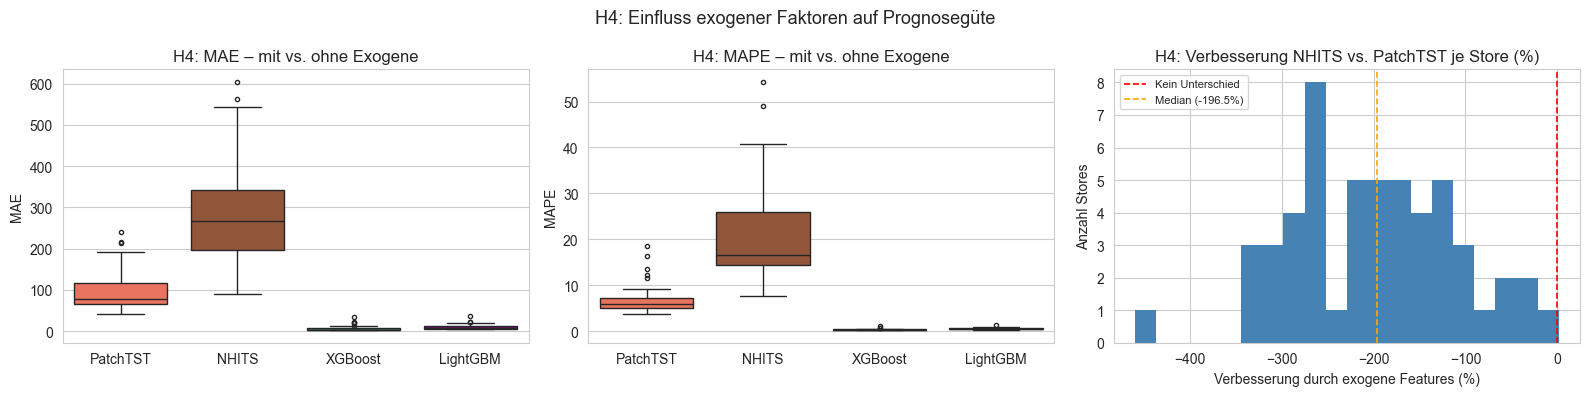

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Boxplot MAE
sns.boxplot(
    data=h4_df, x='model', y='MAE',
    order=h4_models,
    palette=[MODELL_COLORS[m] for m in h4_models],
    flierprops={'markersize': 3}, ax=axes[0]
)
axes[0].set_title('H4: MAE – mit vs. ohne Exogene', fontsize=12)
axes[0].set_xlabel('')

# Boxplot MAPE
sns.boxplot(
    data=h4_df, x='model', y='MAPE',
    order=h4_models,
    palette=[MODELL_COLORS[m] for m in h4_models],
    flierprops={'markersize': 3}, ax=axes[1]
)
axes[1].set_title('H4: MAPE – mit vs. ohne Exogene', fontsize=12)
axes[1].set_xlabel('')

# Histogramm: Verbesserung NHITS vs. PatchTST je Store
axes[2].hist(improvement.dropna(), bins=20, color='steelblue', edgecolor='none')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2,
                label='Kein Unterschied')
axes[2].axvline(improvement.median(), color='orange', linestyle='--',
                linewidth=1.2, label=f'Median ({improvement.median():.1f}%)')
axes[2].set_title('H4: Verbesserung NHITS vs. PatchTST je Store (%)',
                  fontsize=12)
axes[2].set_xlabel('Verbesserung durch exogene Features (%)')
axes[2].set_ylabel('Anzahl Stores')
axes[2].legend(fontsize=8)

plt.suptitle('H4: Einfluss exogener Faktoren auf Prognosegüte', fontsize=13)
plt.tight_layout()
plt.show()

## H5: Wenn hochfrequente Einzelhandelsdaten verarbeitet werden, bieten Gradient-Boosting-Verfahren einen signifikanten Effizienzvorteil (Rechenzeit) gegenüber Deep-Learning-Architekturen ohne relevanten Verlust an Prognosegenauigkeit

#### Trainingszeiten stammen aus NB04 (Val-Set Training, gleiche Datenbasis) und wurden in training_times.json weggeschrieben.
#### MAE aus Test-Split (metrics_df) für Effizienz-Frontier Plot. Bestätigt wenn: GB links-unten im Frontier (kurz + genau)

Trainingszeiten geladen:
  SARIMAX         224.6s  (3.7 min)
  Prophet          26.7s  (0.4 min)
  XGBoost          65.4s  (1.1 min)
  LightGBM         26.4s  (0.4 min)
  PatchTST       6627.8s  (110.5 min)
  NHITS          6593.6s  (109.9 min)

── Effizienzübersicht ──
          Trainingszeit (s)  MAE (Test)  Trainingszeit (min)  \
LightGBM               26.4         9.5                  0.4   
Prophet                26.7       248.4                  0.4   
XGBoost                65.4         6.3                  1.1   
SARIMAX               224.6       106.0                  3.7   
NHITS                6593.6       285.4                109.9   
PatchTST             6627.8       101.2                110.5   

          Effizienz (MAE/min)  
LightGBM                23.75  
Prophet                621.00  
XGBoost                  5.73  
SARIMAX                 28.65  
NHITS                    2.60  
PatchTST                 0.92  


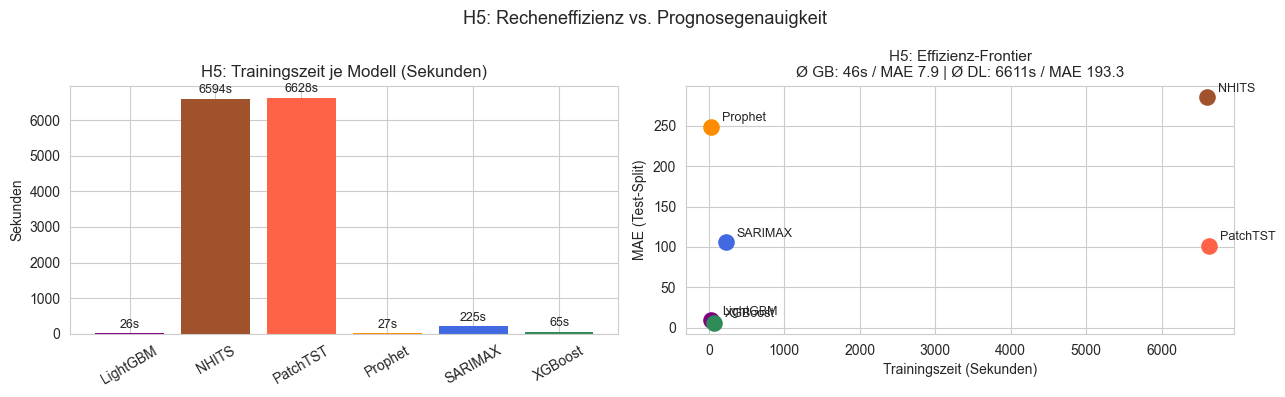


Ø Trainingszeit GB: 46s
Ø Trainingszeit DL: 6611s
Faktor DL/GB:       144.0x langsamer
H5 BESTÄTIGT ✓


In [81]:
times_path = RESULTS / 'training_times.json'
if not times_path.exists():
    print('⚠ training_times.json nicht gefunden.')
    print('  Stelle sicher dass NB04 vollständig ausgeführt wurde.')
    training_times = {}
else:
    with open(times_path, 'r') as f:
        training_times = json.load(f)
    print('Trainingszeiten geladen:')
    for m, t in training_times.items():
        print(f'  {m:<12} {t:>8.1f}s  ({t/60:.1f} min)')

# ── Übersichtstabelle ─────────────────────────────────────────
mae_summary = metrics_df.groupby('model')['MAE'].mean().round(1)

time_df = pd.DataFrame({
    'Trainingszeit (s)': training_times,
    'MAE (Test)':        mae_summary,
}).dropna()

time_df['Trainingszeit (min)'] = (time_df['Trainingszeit (s)'] / 60).round(1)
time_df['Effizienz (MAE/min)'] = (
    time_df['MAE (Test)'] / time_df['Trainingszeit (min)']
).round(2)
print('\n── Effizienzübersicht ──')
print(time_df.sort_values('Trainingszeit (s)').round(2))

if not time_df.empty:
    h5_models = time_df.index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Balkendiagramm: Trainingszeiten ──────────────────────
    colors_h5 = [MODELL_COLORS.get(m, 'gray') for m in h5_models]
    bars = axes[0].bar(
        h5_models,
        time_df.loc[h5_models, 'Trainingszeit (s)'],
        color=colors_h5, edgecolor='none'
    )
    # Zeitwerte über den Balken anzeigen
    for bar, val in zip(bars, time_df.loc[h5_models, 'Trainingszeit (s)']):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(time_df['Trainingszeit (s)']) * 0.01,
            f'{val:.0f}s', ha='center', va='bottom', fontsize=9
        )
    axes[0].set_title('H5: Trainingszeit je Modell (Sekunden)', fontsize=12)
    axes[0].set_ylabel('Sekunden')
    axes[0].tick_params(axis='x', rotation=30)

    # ── Effizienz-Frontier: Zeit vs. MAE ─────────────────────
    # Modelle links-unten sind am effizientesten (schnell + genau)
    for m in h5_models:
        axes[1].scatter(
            time_df.loc[m, 'Trainingszeit (s)'],
            time_df.loc[m, 'MAE (Test)'],
            color=MODELL_COLORS.get(m, 'gray'),
            s=120, zorder=5
        )
        axes[1].annotate(
            m,
            (time_df.loc[m, 'Trainingszeit (s)'],
             time_df.loc[m, 'MAE (Test)']),
            textcoords='offset points',
            xytext=(8, 4), fontsize=9
        )
    axes[1].set_xlabel('Trainingszeit (Sekunden)')
    axes[1].set_ylabel('MAE (Test-Split)')
    axes[1].set_title('H5: Effizienz-Frontier – Zeit vs. Genauigkeit',
                      fontsize=12)

    # ── Interpretation ────────────────────────────────────────
    gb_time = time_df.loc[
        [m for m in ['XGBoost','LightGBM'] if m in time_df.index],
        'Trainingszeit (s)'
    ].mean()
    dl_time = time_df.loc[
        [m for m in ['PatchTST','NHITS'] if m in time_df.index],
        'Trainingszeit (s)'
    ].mean()
    gb_mae_h5 = time_df.loc[
        [m for m in ['XGBoost','LightGBM'] if m in time_df.index],
        'MAE (Test)'
    ].mean()
    dl_mae_h5 = time_df.loc[
        [m for m in ['PatchTST','NHITS'] if m in time_df.index],
        'MAE (Test)'
    ].mean()

    axes[1].set_title(
        f'H5: Effizienz-Frontier\n'
        f'Ø GB: {gb_time:.0f}s / MAE {gb_mae_h5:.1f} | '
        f'Ø DL: {dl_time:.0f}s / MAE {dl_mae_h5:.1f}',
        fontsize=11
    )

    plt.suptitle('H5: Recheneffizienz vs. Prognosegenauigkeit', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\nØ Trainingszeit GB: {gb_time:.0f}s')
    print(f'Ø Trainingszeit DL: {dl_time:.0f}s')
    print(f'Faktor DL/GB:       {dl_time/gb_time:.1f}x langsamer')
    print(f'H5 {"BESTÄTIGT ✓" if gb_time < dl_time and gb_mae_h5 <= dl_mae_h5 * 1.05 else "TEILWEISE ✓" if gb_time < dl_time else "WIDERLEGT ✗"}')

## H6: Wenn eine globale Modellierung aller Filialen erfolgt, dann weisen Deep-Learning-Architekturen bei Filialen mit hoher Varianz eine höhere Generalisierungsfähigkeit und geringere Out-of-Sample-Fehler auf als baumbasierte Verfahren.

#### Metrik: MAE (absolut) und MAPE (relativ/skalierungsunabhängig). Zusätzlich: Korrelation Filialvarianz vs. MAPE je Modell. Bestätigt wenn: DL höhere MAPE bei Typ A als GB

                        MAE   MAPE
model    store_type               
LightGBM A            20.19   0.62
         B             9.08   0.53
         C             5.50   0.59
         D             8.34   0.57
         E             6.12   0.48
NHITS    A           429.61  14.02
         B           292.45  18.70
         C           220.66  25.01
         D           246.17  19.29
         E           402.53  32.65
PatchTST A           176.20   5.44
         B           102.59   6.29
         C            62.77   6.99
         D            97.70   6.93
         E           108.15   8.77
XGBoost  A            16.62   0.48
         B             5.20   0.29
         C             3.17   0.36
         D             4.90   0.34
         E             2.88   0.23

Typ-A Filialen: Ø GB-MAPE 0.55% | Ø DL-MAPE 9.73%
H6 BESTÄTIGT ✓


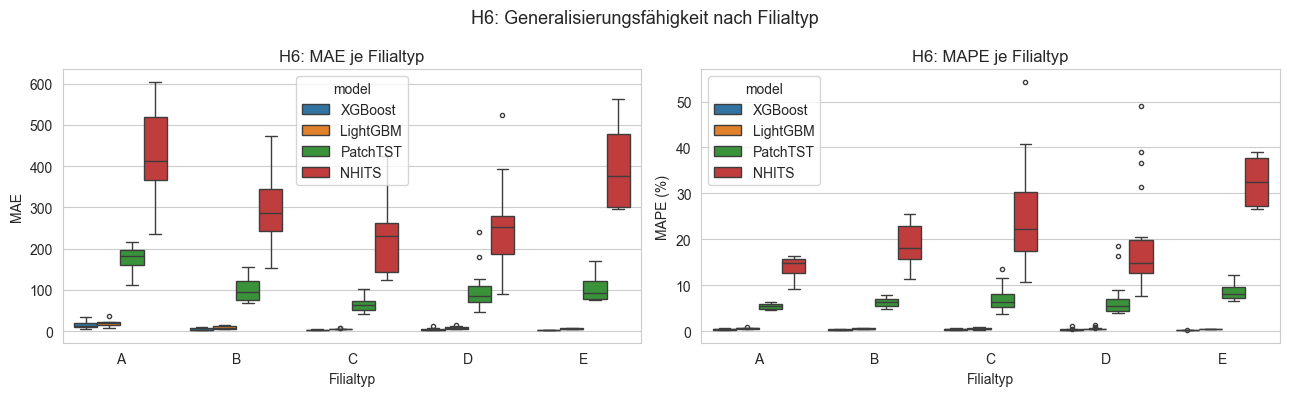

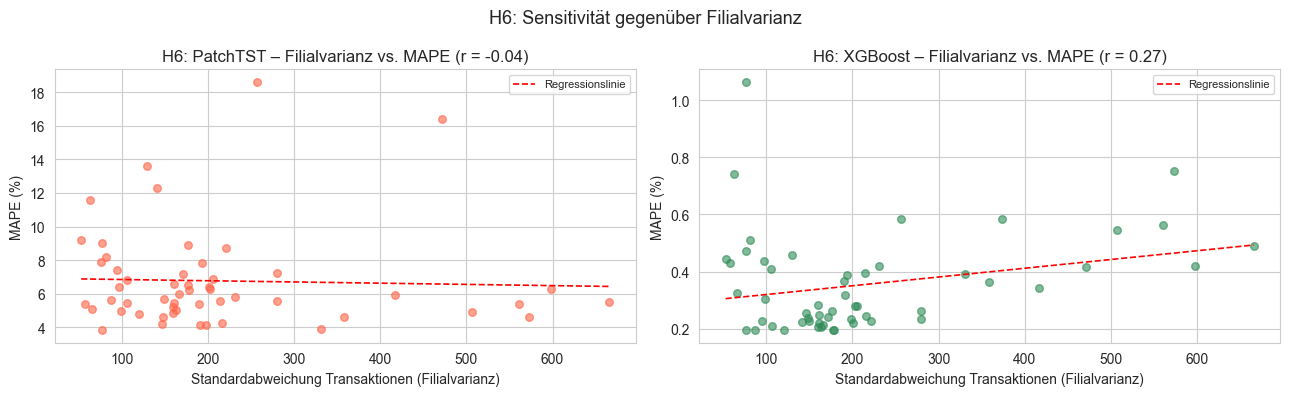

In [82]:

h6_models  = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h6_df      = metrics_df[metrics_df['model'].isin(h6_models)]
type_order = [t for t in ['A', 'B', 'C', 'D', 'E']
              if t in h6_df['store_type'].unique()]

h6_summary = h6_df.groupby(['model', 'store_type'])[['MAE', 'MAPE']].mean().round(2)
print(h6_summary)

# ── Typ-A Vergleich direkt ────────────────────────────────────
typeA = h6_df[h6_df['store_type'] == 'A']
gb_mape_A  = typeA[typeA['model'].isin(['XGBoost','LightGBM'])]['MAPE'].mean()
dl_mape_A  = typeA[typeA['model'].isin(['PatchTST','NHITS'])]['MAPE'].mean()
print(f'\nTyp-A Filialen: Ø GB-MAPE {gb_mape_A:.2f}% | Ø DL-MAPE {dl_mape_A:.2f}%')
print(f'H6 {"BESTÄTIGT ✓" if dl_mape_A > gb_mape_A else "WIDERLEGT ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Boxplot: MAE und MAPE je Filialtyp ───────────────────────
for i, metric in enumerate(['MAE', 'MAPE']):
    sns.boxplot(
        data=h6_df, x='store_type', y=metric,
        hue='model', hue_order=h6_models,
        order=type_order,
        flierprops={'markersize': 3}, ax=axes[i]
    )
    axes[i].set_title(f'H6: {metric} je Filialtyp', fontsize=12)
    axes[i].set_xlabel('Filialtyp')
axes[0].set_ylabel('MAE')
axes[1].set_ylabel('MAPE (%)')
plt.suptitle('H6: Generalisierungsfähigkeit nach Filialtyp', fontsize=13)
plt.tight_layout()
plt.show()

# ── Varianz vs. MAPE: Zeigt ob DL sensibler auf hohe Varianz ─
# Eine stärkere positive Korrelation bei PatchTST als bei XGBoost
# würde bestätigen, dass DL durch hohe Filialvarianz stärker leidet.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, model_name in enumerate(['PatchTST', 'XGBoost']):
    grp = metrics_df[metrics_df['model'] == model_name]
    axes[i].scatter(
        grp['std_true'], grp['MAPE'],
        color=MODELL_COLORS[model_name], alpha=0.6, s=30
    )
    z = np.polyfit(grp['std_true'], grp['MAPE'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(grp['std_true'].min(), grp['std_true'].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.2,
                 linestyle='--', label='Regressionslinie')
    corr = grp['std_true'].corr(grp['MAPE'])
    axes[i].set_title(
        f'H6: {model_name} – Filialvarianz vs. MAPE (r = {corr:.2f})',
        fontsize=12
    )
    axes[i].set_xlabel('Standardabweichung Transaktionen (Filialvarianz)')
    axes[i].set_ylabel('MAPE (%)')
    axes[i].legend(fontsize=8)
plt.suptitle('H6: Sensitivität gegenüber Filialvarianz', fontsize=13)
plt.tight_layout()
plt.show()